# Практическая работа по теме: "Оптимизация гиперпараметров"

## Каримова Идэль ИД24-3

### Классная работа

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.datasets import make_classification
X, Y = make_classification(n_samples=1000, n_classes=2, n_features=5, n_redundant=0, random_state=1)

In [3]:
X.shape, Y.shape

((1000, 5), (1000,))

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)

In [5]:
X_train.shape, Y_train.shape

((800, 5), (800,))

In [6]:
X_test.shape, Y_test.shape

((200, 5), (200,))

In [7]:
import pandas as pd

from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.linear_model import SGDClassifier

In [8]:
names = ["Nearest_Neighbors", "Linear_SVM", "Polynomial_SVM", "RBF_SVM", "Gaussian_Process",
         "Gradient_Boosting", "Decision_Tree", "Extra_Trees", "Random_Forest", "Neural_Net", "AdaBoost",
         "Naive_Bayes", "QDA", "SGD"]

classifiers = [
    KNeighborsClassifier(3),
    SVC(kernel="linear", C=0.025),
    SVC(kernel="poly", degree=3, C=0.025),
    SVC(kernel="rbf", C=1, gamma=2),
    GaussianProcessClassifier(1.0 * RBF(1.0)),
    GradientBoostingClassifier(n_estimators=100, learning_rate=1.0),
    DecisionTreeClassifier(max_depth=5),
    ExtraTreesClassifier(n_estimators=10, min_samples_split=2),
    RandomForestClassifier(max_depth=5, n_estimators=100),
    MLPClassifier(alpha=1, max_iter=1000),
    AdaBoostClassifier(n_estimators=100),
    GaussianNB(),
    QuadraticDiscriminantAnalysis(),
    SGDClassifier(loss="hinge", penalty="l2")]

In [9]:
scores = []
for name, clf in zip(names, classifiers):
    clf.fit(X_train, Y_train)
    score = clf.score(X_test, Y_test)
    scores.append(score)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


In [10]:
df = pd.DataFrame()
df['name'] = names
df['score'] = scores
df.sort_values(by=["score"], ascending=False, inplace=True)
df

,name,score
9,Neural_Net,0.895
11,Naive_Bayes,0.885
13,SGD,0.885
4,Gaussian_Process,0.880
3,RBF_SVM,0.875
8,Random_Forest,0.875
12,QDA,0.875
6,Decision_Tree,0.865
0,Nearest_Neighbors,0.860
7,Extra_Trees,0.860


In [11]:
cm = sns.light_palette("green", as_cmap=True)
s = df.style.background_gradient(cmap=cm)
s


,name,score
9,Neural_Net,0.895000
11,Naive_Bayes,0.885000
13,SGD,0.885000
4,Gaussian_Process,0.880000
3,RBF_SVM,0.875000
8,Random_Forest,0.875000
12,QDA,0.875000
6,Decision_Tree,0.865000
0,Nearest_Neighbors,0.860000
7,Extra_Trees,0.860000


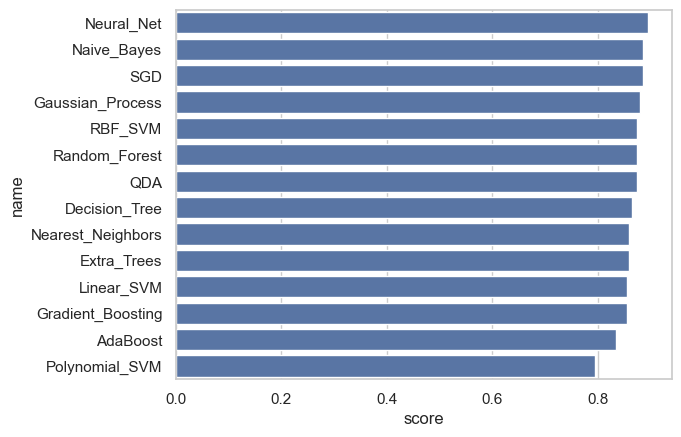

In [12]:
sns.set(style="whitegrid")
ax = sns.barplot(y="name", x="score", data=df)

In [13]:
df = pd.read_csv("https://raw.githubusercontent.com/koroteevmv/ML_course/refs/heads/main/ML4.5%20hyperparameters/data/Advertising.csv")

In [14]:
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [15]:
## Создаём X и y
X = df.drop('sales',axis=1)
y = df['sales']

# Разбиение на обучающий и тестовый наборы - TRAIN TEST SPLIT
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

# Масштабирование данных (SCALE)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [16]:
from sklearn.linear_model import ElasticNet

In [17]:
help(ElasticNet)

Help on class ElasticNet in module sklearn.linear_model._coordinate_descent:

class ElasticNet(sklearn.base.MultiOutputMixin, sklearn.base.RegressorMixin, sklearn.linear_model._base.LinearModel)
 |  ElasticNet(alpha=1.0, *, l1_ratio=0.5, fit_intercept=True, precompute=False, max_iter=1000, copy_X=True, tol=0.0001, warm_start=False, positive=False, random_state=None, selection='cyclic')
 |
 |  Linear regression with combined L1 and L2 priors as regularizer.
 |
 |  Minimizes the objective function::
 |
 |          1 / (2 * n_samples) * ||y - Xw||^2_2
 |          + alpha * l1_ratio * ||w||_1
 |          + 0.5 * alpha * (1 - l1_ratio) * ||w||^2_2
 |
 |  If you are interested in controlling the L1 and L2 penalty
 |  separately, keep in mind that this is equivalent to::
 |
 |          a * ||w||_1 + 0.5 * b * ||w||_2^2
 |
 |  where::
 |
 |          alpha = a + b and l1_ratio = a / (a + b)
 |
 |  The parameter l1_ratio corresponds to alpha in the glmnet R package while
 |  alpha corresponds to

In [18]:
base_elastic_model = ElasticNet()

In [19]:
param_grid = {'alpha':[0.1,1,5,10,50,100],
              'l1_ratio':[.1, .5, .7, .9, .95, .99, 1]}

In [20]:
from sklearn.model_selection import GridSearchCV

In [21]:
# число verbose выбирайте сами
grid_model = GridSearchCV(estimator=base_elastic_model,
                          param_grid=param_grid,
                          scoring='neg_mean_squared_error',
                          cv=5,
                          verbose=2)

In [22]:
grid_model.fit(X_train, y_train)

Fitting 5 folds for each of 42 candidates, totalling 210 fits
[CV] END ............................alpha=0.1, l1_ratio=0.1; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.1; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.1; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.1; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.1; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.5; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.5; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.5; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.5; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.5; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.7; total time=   0.0s
[CV] END ............................alpha=0.1,

GridSearchCV(cv=5, estimator=ElasticNet(),
             param_grid={'alpha': [0.1, 1, 5, 10, 50, 100],
                         'l1_ratio': [0.1, 0.5, 0.7, 0.9, 0.95, 0.99, 1]},
             scoring='neg_mean_squared_error', verbose=2)

In [23]:
grid_model.best_estimator_

ElasticNet(alpha=0.1, l1_ratio=1)

In [26]:
y_pred = grid_model.predict(X_test)

In [27]:
from sklearn.metrics import mean_squared_error
mean_squared_error(y_test,y_pred)

2.3873426420874737

### Домашнее задание

In [55]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV

1. При выборе модели мы обычно выбираем ту, которая дает наибольшее значение какой-то метрики. Но это означает, что эта оценка метрики уже становится завышенной. Поэтому для объективной оценки качества модели ее опять следует оценить на новом наборе данных. Поэтому для выбора модели нужно разделить выборку на три части - обучающую, валидационную и тестовую. Повторите первую часть работы, но с таким разбиением и получите несмещенную оценку качества наилучшей модели.

In [36]:
X, y = make_classification(n_samples=1000, n_features=5, n_classes=2, random_state=1)

In [37]:
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25)

In [38]:
models = {
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(),
    "RandomForest": RandomForestClassifier()
}

In [39]:
best_model = None
best_score = 0
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_val)

    acc = accuracy_score(y_val, pred)
    f1 = f1_score(y_val, pred)

    print(name, "Accuracy:", acc, "F1:", f1)

    if f1 > best_score:
        best_score = f1
        best_model = model
pred_test = best_model.predict(X_test)

KNN Accuracy: 0.835 F1: 0.8272251308900523
SVM Accuracy: 0.835 F1: 0.8307692307692308
RandomForest Accuracy: 0.84 F1: 0.8279569892473119


2. Оптимизируйте гиперпараметры той же модели, но другим методом - случайным поиском. Сравните полученные результаты.



In [41]:
df = pd.read_csv("https://raw.githubusercontent.com/koroteevmv/ML_course/refs/heads/main/ML4.5%20hyperparameters/data/Advertising.csv")

In [42]:
X = df.drop("sales", axis=1)
y = df["sales"]

In [43]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

In [46]:
model = ElasticNet()

In [47]:
param_dist = {
    "alpha": [0.1, 1, 5, 10, 50, 100],
    "l1_ratio": [0.1, 0.5, 0.7, 0.9, 1]
}

In [48]:
random_search = RandomizedSearchCV(
    model,
    param_distributions=param_dist,
    n_iter=10,
    scoring='neg_mean_squared_error',
    cv=5
)


In [49]:
random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=ElasticNet(),
                   param_distributions={'alpha': [0.1, 1, 5, 10, 50, 100],
                                        'l1_ratio': [0.1, 0.5, 0.7, 0.9, 1]},
                   scoring='neg_mean_squared_error')

In [50]:
print("Лучшие параметры:", random_search.best_params_)
y_pred = random_search.predict(X_test)
print("MSE:", mean_squared_error(y_test, y_pred))



Лучшие параметры: {'l1_ratio': 0.1, 'alpha': 0.1}
MSE: 2.6440130034156977


3. Во второй задаче найдите наиболее эффективный класс моделей, а затем оптимизируйте гиперпараметры у этой модели. Сравните, насколько лучше получилась модель.



In [65]:
X, y = make_classification(n_samples=1000, n_features=5, n_classes=2, random_state=1)

In [66]:
models = {
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(),
    "RandomForest": RandomForestClassifier()
}

In [67]:
best_model = None
best_score = 0

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    score = f1_score(y_test, pred)

    print(name, "F1:", score)

    if score > best_score:
        best_score = score
        best_model = name

print("\nЛучшая модель:", best_model)


KNN F1: 1.0
SVM F1: 1.0
RandomForest F1: 1.0

Лучшая модель: KNN


In [68]:
param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [3, 5, 10]
}

In [69]:
grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=5)
grid.fit(X_train, y_train)


GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'max_depth': [3, 5, 10], 'n_estimators': [50, 100]})

In [71]:
print("Лучшие параметры:", grid.best_params_)

pred = grid.predict(X_test)
print("F1 после оптимизации:", f1_score(y_test, pred))


Лучшие параметры: {'max_depth': 3, 'n_estimators': 50}
F1 после оптимизации: 1.0



4. Выбирите любой датасет. Обучите несколько моделий. На лучшей модели подберите гиперпараметры с помощью библиотек Optuna или Hyperopt


In [63]:
pip install optuna

   ---------------------------------------- 0.0/419.5 kB ? eta -:--:--
   --- ----------------------------------- 41.0/419.5 kB 653.6 kB/s eta 0:00:01
   ----------- ---------------------------- 122.9/419.5 kB 1.2 MB/s eta 0:00:01
   ------------------------ --------------- 256.0/419.5 kB 1.7 MB/s eta 0:00:01
   ----------------------------------- ---- 368.6/419.5 kB 1.9 MB/s eta 0:00:01
   ---------------------------------------- 419.5/419.5 kB 1.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/263.9 kB ? eta -:--:--
   ------------------------------------- - 256.0/263.9 kB 16.4 MB/s eta 0:00:01
   ---------------------------------------- 263.9/263.9 kB 5.5 MB/s eta 0:00:00
   ---------------------------------------- 0.0/78.5 kB ? eta -:--:--
   ---------------------------------------- 78.5/78.5 kB 2.2 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [72]:
import optuna
from sklearn.datasets import load_iris

In [73]:
data = load_iris()
X = data.data
y = data.target

In [74]:
X = X[y != 2]
y = y[y != 2]

In [75]:
X_train, X_test, y_train, y_test = train_test_split(X, y)

In [77]:
study = optuna.create_study(direction="maximize")

[I 2026-03-17 15:44:45,486] A new study created in memory with name: no-name-0bacbaac-4dd0-4c43-9abf-dc1ea1ae0ddd


In [78]:
for _ in range(10):
    trial = study.ask()
    n_estimators = trial.suggest_int("n_estimators", 10, 100)
    max_depth = trial.suggest_int("max_depth", 2, 10)

    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth
    )

    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    score = f1_score(y_test, pred)
    study.tell(trial, score)

print("Лучшие параметры:", study.best_params)

Лучшие параметры: {'n_estimators': 27, 'max_depth': 4}
